
<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.5’

survey-results-publ 100%[===================>] 201.62M  3.71MB/s    in 39s     
2026-09-03 08:35:53 (5.12 MB/s) - ‘survey-results-public.sqlite.5’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 176.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 191.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 193.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 170.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 153.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [5]:
!pip install seaborn 

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [8]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [9]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [6]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


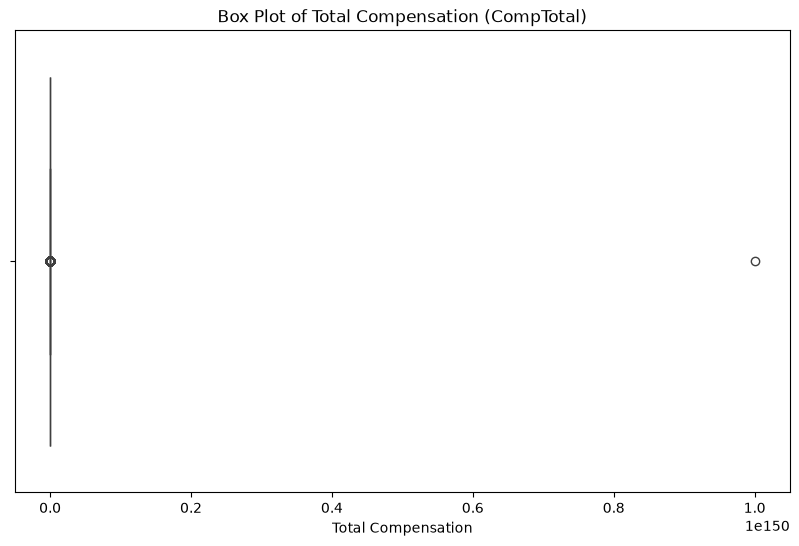

In [10]:
# your code goes here

import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

#Query Comptotal from the main table 
QUERY = """
SELECT CompTotal 
FROM main 
"""
df_comp = pd.read_sql_query(QUERY, conn)

#Create the box plot
plt.figure(figsize=(10,6))
sns.boxplot(x=df_comp["CompTotal"].dropna())

plt.title("Box Plot of Total Compensation (CompTotal)")
plt.xlabel("Total Compensation")
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


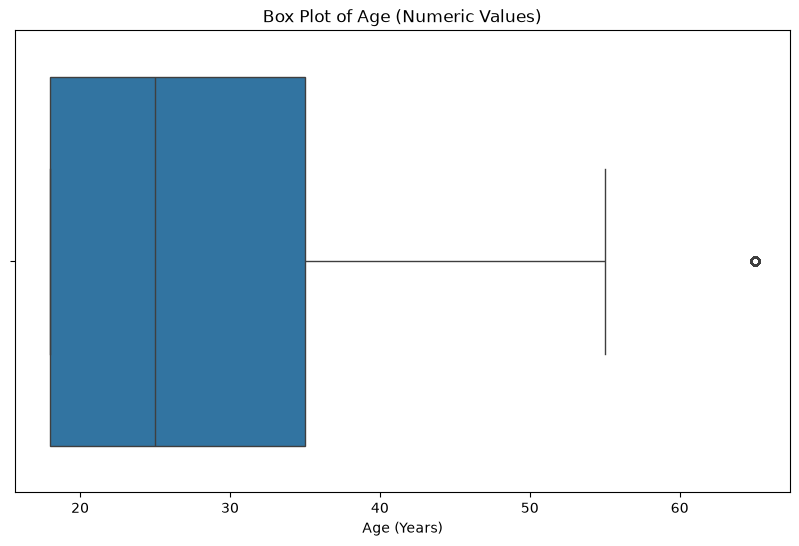

In [11]:
# your code goes here
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns 

#Query the age column from the main table
QUERY = """
SELECT Age 
FROM main 
"""
df_age = pd.read_sql_query(QUERY, conn)

#Extract the lower bound numerical value from the Age text 
df_age["Age_Numeric"] = (df_age["Age"].str.extract(r"(\d+)").astype(float) )

#Create the box plot
plt.figure(figsize=(10,6))
sns.boxplot(x=df_age["Age_Numeric"].dropna())

plt.title("Box Plot of Age (Numeric Values)")
plt.xlabel("Age (Years)")
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


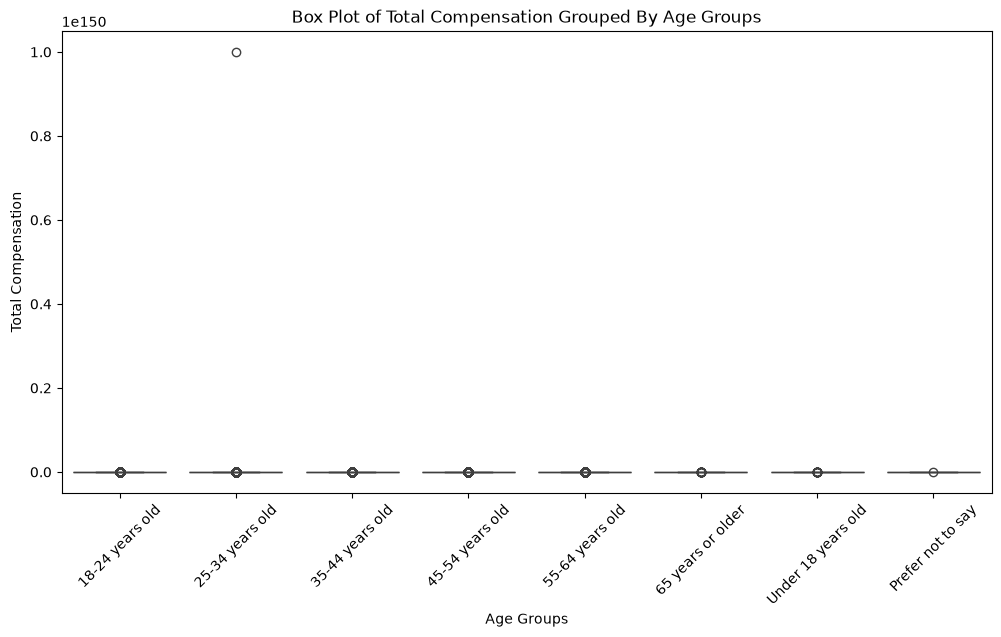

In [7]:
# your code goes here
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns 

#query comptotal and age from the database 
QUERY = """
SELECT CompTotal, Age 
FROM main 
"""
df_age_comp = pd.read_sql_query(QUERY, conn)
#drop missing values in both columns 
df_age_comp = df_age_comp.dropna(subset=["CompTotal","Age"])

#Create the grouped Box Plot
plt.figure(figsize=(12,6))
sns.boxplot(x="Age",y= "CompTotal",data= df_age_comp)

plt.title("Box Plot of Total Compensation Grouped By Age Groups")
plt.xlabel("Age Groups")
plt.ylabel("Total Compensation")
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


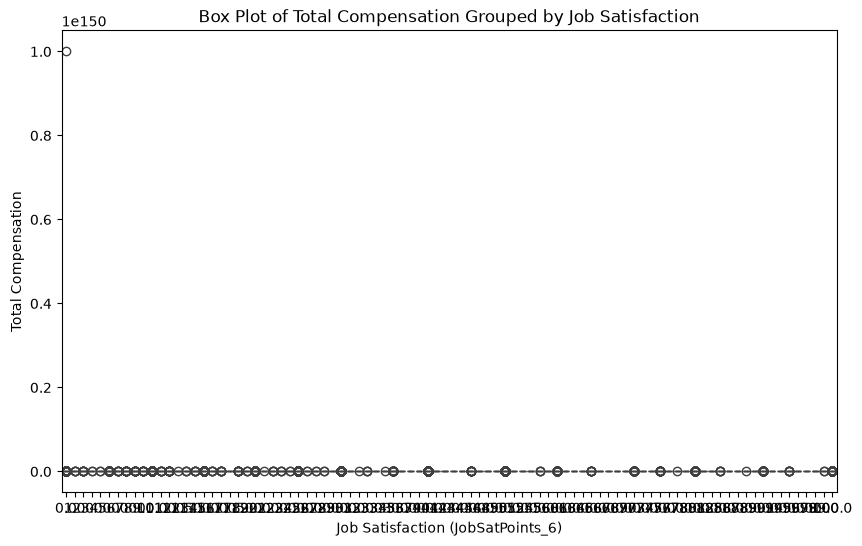

In [12]:
#your code goes here
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

#Query CompTotal and JobSatPoints_6 from the main table

QUERY = """
SELECT CompTotal, JobSatPoints_6
FROM main 
"""
df_jobsat_comp = pd.read_sql_query(QUERY,conn)

#Drop missing values in both columns 
df_jobsat_comp = df_jobsat_comp.dropna(subset=["CompTotal","JobSatPoints_6"])

#Create the Box PLot 
plt.figure(figsize= (10,6))
sns.boxplot(x= "JobSatPoints_6", y="CompTotal", data= df_jobsat_comp)

plt.title("Box Plot of Total Compensation Grouped by Job Satisfaction")
plt.xlabel("Job Satisfaction (JobSatPoints_6)")
plt.ylabel("Total Compensation")
plt.show()


### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


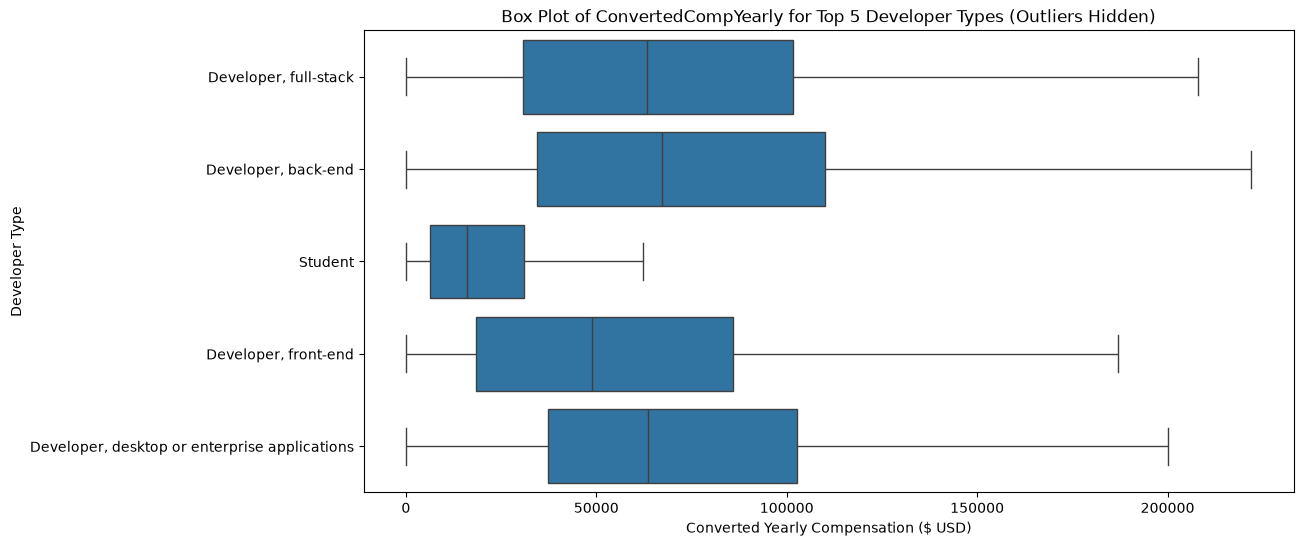

In [13]:
# your code goes here
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Find the top 5 developer types (DevType) by count
top_5_roles_query = """
SELECT DevType
FROM main
WHERE DevType IS NOT NULL
GROUP BY DevType
ORDER BY COUNT(*) DESC
LIMIT 5
"""
top_5_roles = pd.read_sql_query(top_5_roles_query, conn)["DevType"].tolist()

# 2. Query ConvertedCompYearly and DevType for those top 5 roles
QUERY = """
SELECT ConvertedCompYearly, DevType
FROM main
WHERE DevType IN ({})
""".format(
    ",".join(["?"] * len(top_5_roles))
)

df_dev_comp = pd.read_sql_query(QUERY, conn, params=top_5_roles)

# 3. Clean missing values
df_dev_comp = df_dev_comp.dropna(subset=["ConvertedCompYearly", "DevType"])

# 4. Create the Box Plot (Horizontal orientation for clear role label readability)
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="ConvertedCompYearly",
    y="DevType",
    data=df_dev_comp,
    order=top_5_roles,
    showfliers=False,  # Set to True if you want to display extreme outliers
)

plt.title(
    "Box Plot of ConvertedCompYearly for Top 5 Developer Types (Outliers Hidden)"
)
plt.xlabel("Converted Yearly Compensation ($ USD)")
plt.ylabel("Developer Type")
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


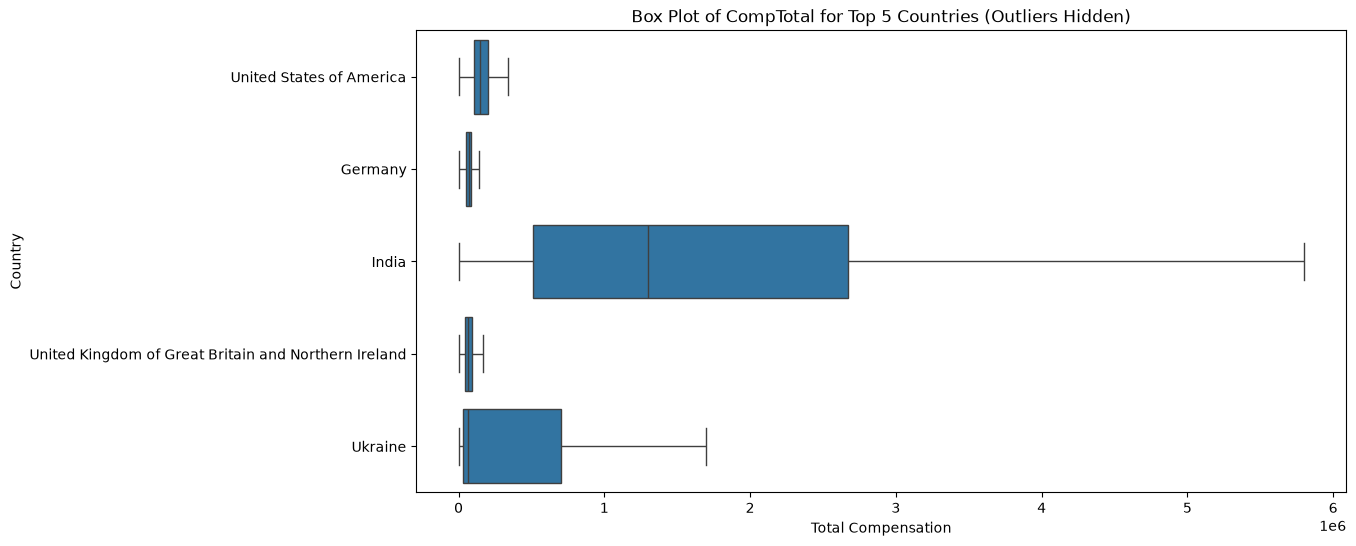

In [14]:
# your code goes here
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Find the top 5 countries by respondent count
top_5_countries_query = """
SELECT Country
FROM main
WHERE Country IS NOT NULL
GROUP BY Country
ORDER BY COUNT(*) DESC
LIMIT 5
"""
top_5_countries = pd.read_sql_query(top_5_countries_query, conn)["Country"].tolist()

# 2. Query CompTotal and Country for those top 5 countries
QUERY_COUNTRY = """
SELECT CompTotal, Country
FROM main
WHERE Country IN ({})
""".format(",".join(["?"] * len(top_5_countries)))

df_country_comp = pd.read_sql_query(QUERY_COUNTRY, conn, params=top_5_countries)

# 3. Clean missing values
df_country_comp = df_country_comp.dropna(subset=["CompTotal", "Country"])

# 4. Create the Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="CompTotal", 
    y="Country", 
    data=df_country_comp, 
    order=top_5_countries, 
    showfliers=False  # Hide extreme outliers for better scale visualization
)

plt.title("Box Plot of CompTotal for Top 5 Countries (Outliers Hidden)")
plt.xlabel("Total Compensation")
plt.ylabel("Country")
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


/tmp/ipykernel_382/3600277567.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

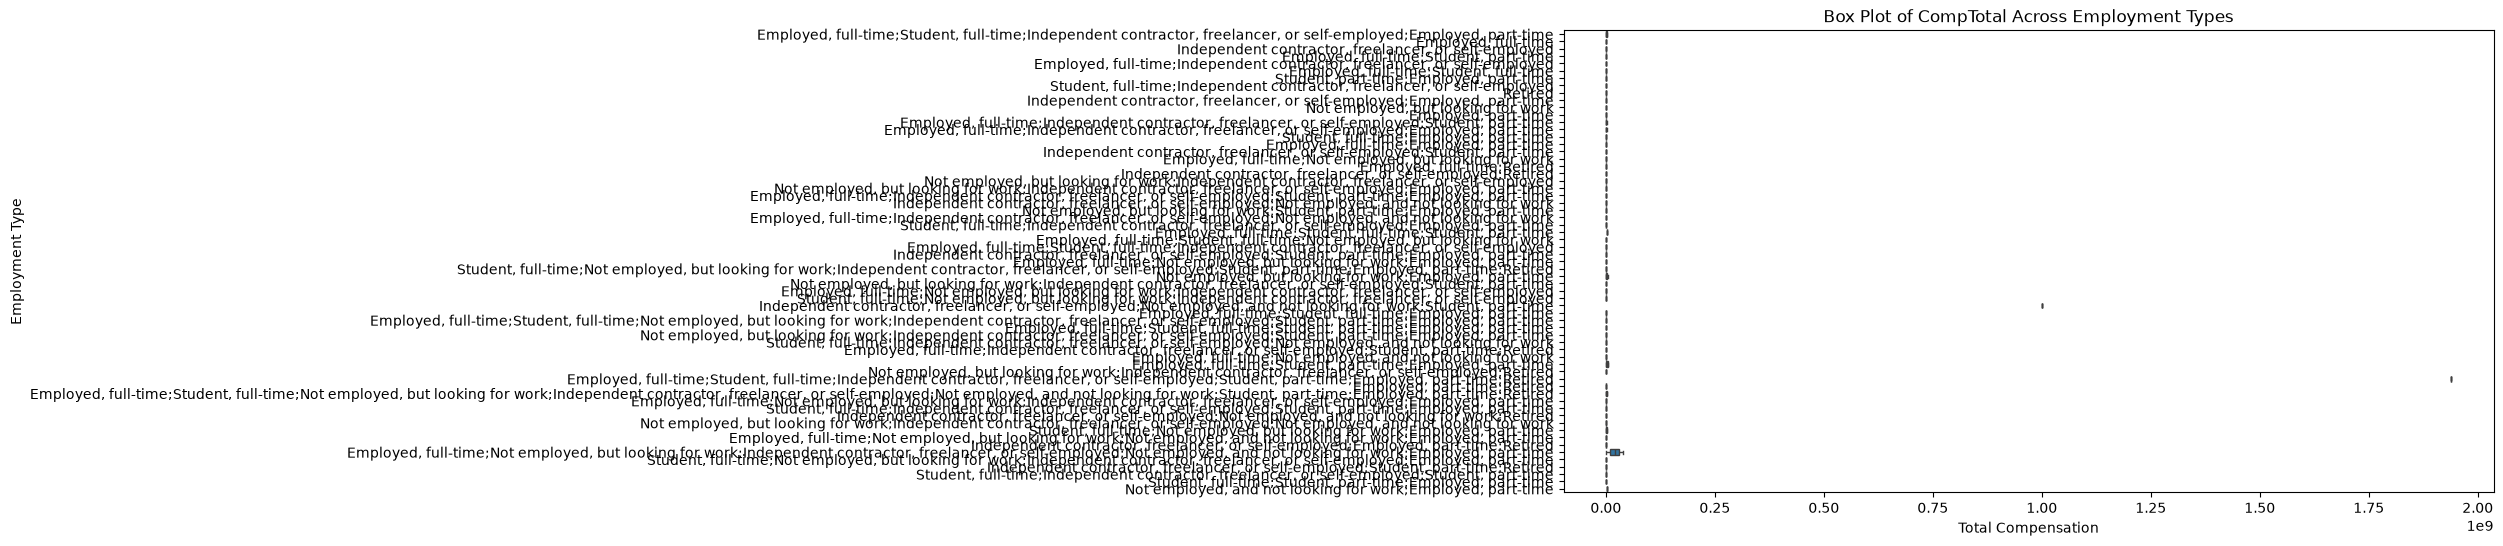

In [15]:
# your code goes here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Query CompTotal and Employment from the table 'main'
query = """
SELECT CompTotal, Employment 
FROM main 
WHERE CompTotal IS NOT NULL AND Employment IS NOT NULL
"""
df_employment = pd.read_sql_query(query, conn)

# 2. Create the Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="CompTotal", 
    y="Employment", 
    data=df_employment, 
    showfliers=False  # Hide extreme outliers for better visual clarity
)

plt.title("Box Plot of CompTotal Across Employment Types")
plt.xlabel("Total Compensation")
plt.ylabel("Employment Type")
plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


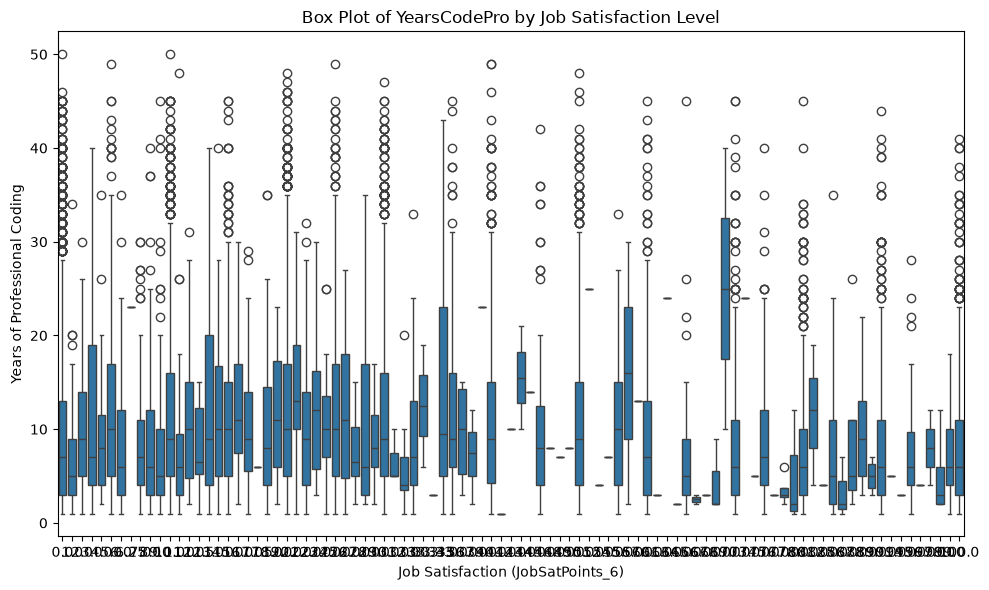

In [16]:
# your code goes here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Query YearsCodePro and JobSatPoints_6 from the table 'main'
query = """
SELECT YearsCodePro, JobSatPoints_6 
FROM main 
WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL
"""
df_jobsat = pd.read_sql_query(query, conn)

# Ensure YearsCodePro is numeric
df_jobsat['YearsCodePro'] = pd.to_numeric(df_jobsat['YearsCodePro'], errors='coerce')

# 2. Create the Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="JobSatPoints_6", 
    y="YearsCodePro", 
    data=df_jobsat
)

plt.title("Box Plot of YearsCodePro by Job Satisfaction Level")
plt.xlabel("Job Satisfaction (JobSatPoints_6)")
plt.ylabel("Years of Professional Coding")
plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [17]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.



<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [ ]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.6’

public.sqlite.6      61%[===========>        ] 123.90M  11.2MB/s    eta 8s     

#### 2. Connect to the Database


**Install the needed libraries**


In [18]:
!pip install pandas

In [19]:
!pip install matplotlib

In [15]:
!pip install seaborn 

In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [21]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [22]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [23]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


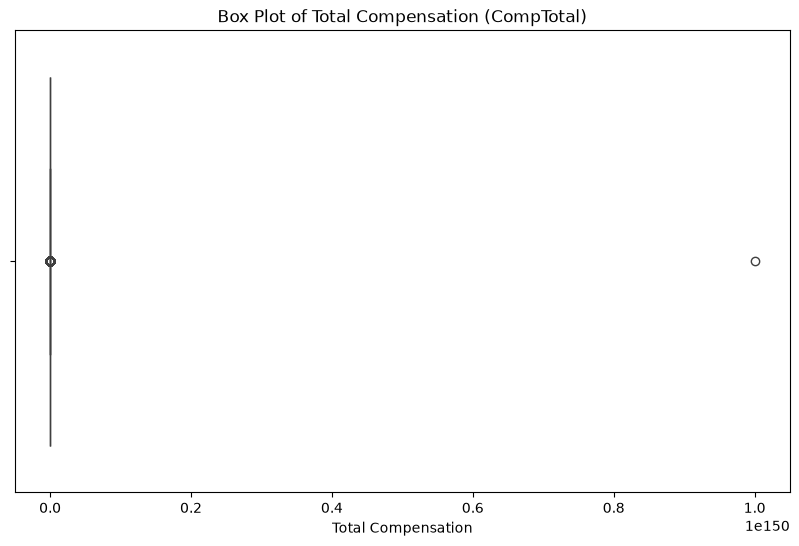

In [24]:
# your code goes here

import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

#Query Comptotal from the main table 
QUERY = """
SELECT CompTotal 
FROM main 
"""
df_comp = pd.read_sql_query(QUERY, conn)

#Create the box plot
plt.figure(figsize=(10,6))
sns.boxplot(x=df_comp["CompTotal"].dropna())

plt.title("Box Plot of Total Compensation (CompTotal)")
plt.xlabel("Total Compensation")
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [30]:
# your code goes here
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as seabornns 

#Query the age column from the main table
QUERY = """
SELECT Age 
FROM main 
"""
df_age = pd.read_sql_query(QUERY, conn)

#Extract the lower bound numerical value from the Age text 
df_age["Age_Numeric"] = (df_age["Age"].str.extract(r"(\d+)").astype(float) )

#Create the box plot
plt.figure(figsize=(10,6))
sns.boxplot(x=df_age["Age_Numeric"].dropna())

plt.title("Box Plot of Age (Numeric Values)")
plt.xlabel("Age (Years)")
plt.show()

ProgrammingError: Cannot operate on a closed database.

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [31]:
# your code goes here


**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [32]:
# your code goes here

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [34]:
# your code goes here

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [33]:
# your code goes here

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [29]:
# your code goes here

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [28]:
# your code goes here

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [27]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
